In [27]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.plotting import (analyze_attention_ROI, barplot_morey,
                                plot_decoding_nvoxels)

In [28]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. Visual modality: t(23)=3.8526, p=0.0004. Auditory modality: t(23)=1.7065, p=0.0945
24 subjects in 100 voxels mask. Visual modality: t(23)=4.9108, p=0.0000. Auditory modality: t(23)=4.3278, p=0.0001
23 subjects in 150 voxels mask. Visual modality: t(22)=6.4608, p=0.0000. Auditory modality: t(22)=3.9624, p=0.0003
23 subjects in 200 voxels mask. Visual modality: t(22)=6.2898, p=0.0000. Auditory modality: t(22)=5.0205, p=0.0000
23 subjects in 250 voxels mask. Visual modality: t(22)=6.9007, p=0.0000. Auditory modality: t(22)=5.5404, p=0.0000
23 subjects in 300 voxels mask. Visual modality: t(22)=7.8709, p=0.0000. Auditory modality: t(22)=5.3253, p=0.0000
23 subjects in 350 voxels mask. Visual modality: t(22)=8.0259, p=0.0000. Auditory modality: t(22)=4.5688, p=0.0000
24 subjects in funcloc voxels mask. Visual modality: t(23)=6.4012, p=0.0000. Auditory modality: t(23)=5.3528, p=0.0000
25 subjects in wholeROI voxels mask. Visual modality: t(24)=5.7604, p=0.0000.

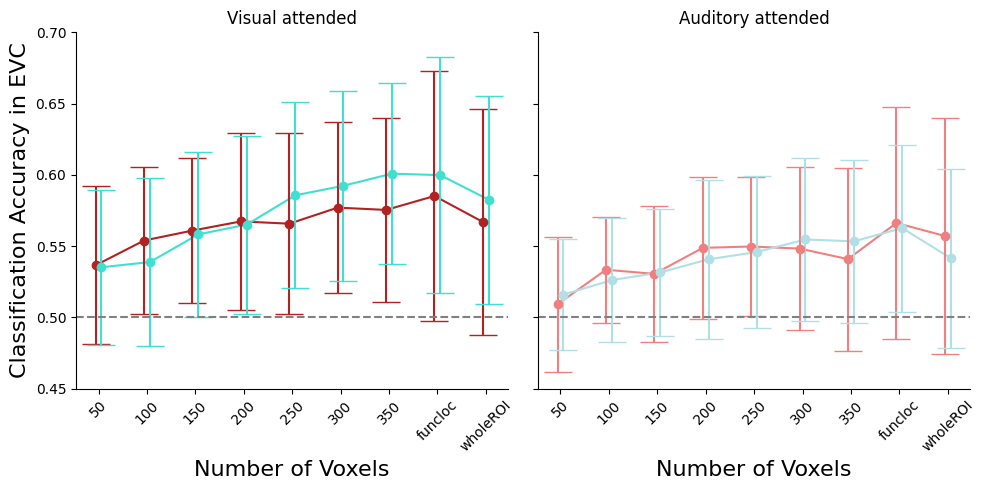

In [ ]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred", save_fig=False)

## Analyze specific ROIs

In [23]:
ROI = "EVC"
n_voxels = "funcloc"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[
    "correct"
].mean()

### Attention * visual prediction

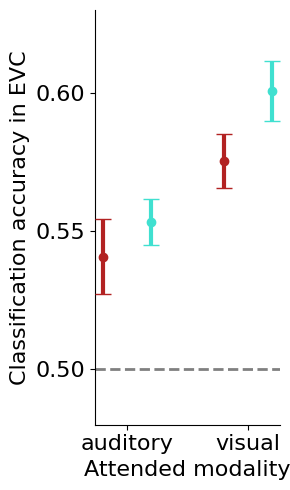

In [19]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [12]:
df["correct"].mean()

np.float64(0.568023097826087)

In [10]:
df.groupby(["modality"])["correct"].mean()

modality
auditory    0.549312
visual      0.574721
Name: correct, dtype: float64

In [11]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,1.613959e-02,1,24,1.613959e-02,3.725103,0.065501,0.065501,2.005266e-02,1.0
1,v_pred,8.506944e-08,1,24,8.506944e-08,0.000022,0.996300,0.996300,1.078575e-07,1.0
2,modality * v_pred,6.071007e-03,1,24,6.071007e-03,2.557319,0.122868,0.122868,7.638489e-03,1.0


In [12]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.930053,24.0,two-sided,0.065501,NaN,NaN,1.037,-0.306600
1,v_pred,-,0,1,True,True,-0.004685,24.0,two-sided,0.996300,NaN,NaN,0.211,-0.000710
2,modality * v_pred,auditory,0,1,True,True,0.837512,24.0,two-sided,0.410568,0.410568,fdr_bh,0.29,0.171849
3,modality * v_pred,visual,0,1,True,True,-1.251142,24.0,two-sided,0.222942,0.410568,fdr_bh,0.423,-0.166752


### Multimodal analyses

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotti

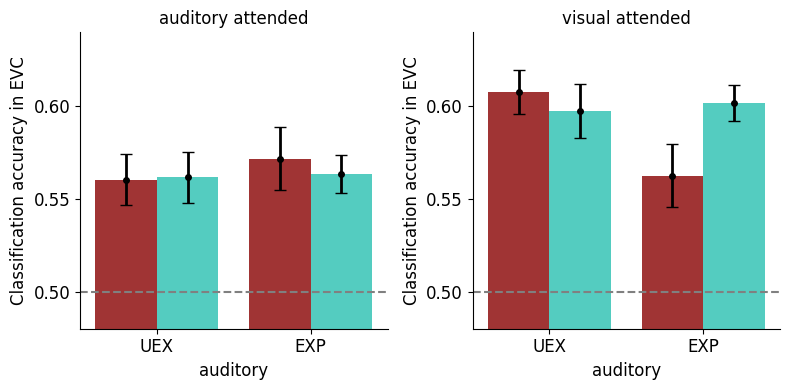

In [24]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)

In [25]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.000998,1,23,0.000998,0.179634,0.675626,0.675626,0.001155,1.0
1,auditory attended,1,v_pred,0.000305,1,23,0.000305,0.065523,0.800246,0.800246,0.000354,1.0
2,auditory attended,2,a_pred * v_pred,0.000569,1,23,0.000569,0.157653,0.694987,0.694987,0.000659,1.0
3,visual attended,0,a_pred,0.010072,1,23,0.010072,2.492549,0.128042,0.128042,0.008827,1.0
4,visual attended,1,v_pred,0.005141,1,23,0.005141,1.063559,0.313128,0.313128,0.004525,1.0
5,visual attended,2,a_pred * v_pred,0.014484,1,23,0.014484,3.261630,0.084024,0.084024,0.012644,1.0


In [26]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,auditory attended,0,a_pred,-,0,1,True,True,-0.423832,23.0,two-sided,0.675626,NaN,NaN,0.233,-0.075410
1,auditory attended,1,v_pred,-,0,1,True,True,0.255974,23.0,two-sided,0.800246,NaN,NaN,0.221,0.042367
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,-0.070689,23.0,two-sided,0.944256,0.944256,fdr_bh,0.215,-0.012772
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,0.450950,23.0,two-sided,0.656248,0.944256,fdr_bh,0.236,0.092214
4,visual attended,0,a_pred,-,0,1,True,True,1.578781,23.0,two-sided,0.128042,NaN,NaN,0.636,0.205114
5,visual attended,1,v_pred,-,0,1,True,True,-1.031290,23.0,two-sided,0.313128,NaN,NaN,0.346,-0.145101
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,0.520853,23.0,two-sided,0.607448,0.607448,fdr_bh,0.243,0.089769
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-1.937597,23.0,two-sided,0.065046,0.130093,fdr_bh,1.059,-0.352750


In [14]:
df_grouped.groupby(["modality", "a_pred", "v_pred"])["correct"].mean().unstack()

v_pred                 0         1
modality a_pred                   
auditory 0       0.55055  0.538183
         1       0.56360  0.544917
visual   0       0.58775  0.582083
         1       0.54605  0.583000